# 03_dataset_construction.ipynb

Construye el dataset final unificado a partir de los 9 parquets generados en `02_feature_engineering`.

**Entrada:** `data/processed/*.parquet` — 9 archivos, 1,155,302 filas  
**Salida:** `data/processed/dataset_final.parquet`

Schema: `sample_id` | 72 features (`float32`) | `label` (`int8`) | `timestamp`

Distribucion de clases (sin resampleo):
- 0 `legitimate`       : 743,708  (64.4%)
- 1 `sqli`             : 295,690  (25.6%)
- 2 `xss`              :  36,606   (3.2%)
- 3 `path_traversal`   :  69,310   (6.0%)
- 4 `command_injection`:   9,988   (0.9%)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")

SOURCES = [
    "payloads_csv", "payload_full", "command_injection",
    "xss_dataset", "data_capec", "modsec_learn",
    "pt_wordlists", "owasp_logs", "russellmitchell",
]

LABEL = {0: "legitimate", 1: "sqli", 2: "xss", 3: "path_traversal", 4: "command_injection"}

print(f"PROCESSED_DIR = {PROCESSED_DIR.resolve()}")
print(f"Fuentes       = {len(SOURCES)}")

PROCESSED_DIR = C:\Users\thiag\Universidad\logSguarDian\data\processed
Fuentes       = 9


# Seccion 1: Carga y concatenacion

Se cargan los 9 parquets y se concatenan en un unico DataFrame.
El `sample_id` original de cada fuente se preserva para trazabilidad al crudo.
El dataset final se guarda en `data/processed/dataset_final.parquet`.

In [3]:
frames = []
for name in SOURCES:
    fpath = PROCESSED_DIR / f"{name}.parquet"
    df = pd.read_parquet(fpath)
    frames.append(df)
    dist = df["label"].value_counts().sort_index()
    dist_str = "  ".join(f"{LABEL[int(k)]}:{v:,}" for k, v in dist.items())
    print(f"  {name:<23} {len(df):>8,}  {dist_str}")

df_final = pd.concat(frames, ignore_index=True)

out_path = PROCESSED_DIR / "dataset_final.parquet"
df_final.to_parquet(out_path, index=False, engine="pyarrow")

size_mb = out_path.stat().st_size / (1024**2)
print(f"\ndataset_final.parquet  {len(df_final):>10,} filas  {size_mb:.1f} MB  {len(df_final.columns)} cols")

  payloads_csv              42,671  legitimate:28,068  xss:14,603
  payload_full              31,067  legitimate:19,304  sqli:10,852  xss:532  path_traversal:290  command_injection:89
  command_injection          2,059  legitimate:1,581  command_injection:478
  xss_dataset               13,686  legitimate:6,313  xss:7,373
  data_capec               905,069  legitimate:615,906  sqli:250,230  xss:13,838  path_traversal:18,005  command_injection:7,090
  modsec_learn              99,645  legitimate:69,101  sqli:30,544
  pt_wordlists               1,166  path_traversal:1,166
  owasp_logs                56,504  sqli:4,064  xss:260  path_traversal:49,849  command_injection:2,331
  russellmitchell            3,435  legitimate:3,435

dataset_final.parquet   1,155,302 filas  10.5 MB  75 cols


# Seccion 2: Estructura del dataset

Schema uniforme en todos los parquets:
- `sample_id`: string con prefijo de fuente para trazabilidad
- 72 features nombradas en `float32` (9 grupos semanticos)
- `label`: entero `int8` en rango 0-4
- `timestamp`: `datetime64` (real donde disponible, 2026-06-08 en fuentes sin timestamp)

Los 72 features se distribuyen en 9 grupos:

| Grupo | Features |
|---|---|
| Longitudes (8) | payload_length, uri_length, path_length, query_string_length, body_length, path_depth, query_param_count, fragment_present |
| Composicion (10) | special_char_ratio, numeric_char_ratio, uppercase_ratio, whitespace_count, newline_char_count, null_byte_count, extended_ascii_ratio, payload_token_count, payload_entropy, body_entropy |
| Encoding (7) | url_encoded_ratio, encoded_char_freq, double_encoded_count, hex_escape_count, unicode_escape_count, html_entity_count, base64_like_count |
| SQLi (10) | sqli_keyword_count/density, sqli_comment_count, sqli_operator_count, quote_count, semicolon_count, parenthesis_count, union_present, select_present |
| XSS (9) | xss_marker_count/density, html_tag_count, script_tag_present, js_event_handler_count, javascript_url_count, html_entity_density, alert_function_present, inline_style_present |
| Path Traversal (7) | traversal_sequence_count, path_separator_count, absolute_path_indicator, sensitive_file_target, sensitive_extension_count, file_extension_suspicious, dotdot_encoded_count |
| Command Injection (8) | pipe_count, backtick_count, shell_command_count, command_separator_count, redirect_operator_count, dollar_sign_count, subshell_count, os_path_indicator |
| HTTP (9) | method_is_get, method_is_post, ua_present, ua_length, ua_suspicious, content_type_encoded, authorization_length, unusual_headers_count, status_code |
| Temporales (5) | req_count_1s, req_count_5s, req_count_60s, error_rate_4xx_60s, endpoint_diversity_60s |

In [4]:
print(f"Shape : {df_final.shape}")
print(f"Cols  : {list(df_final.columns[:5])} ... {list(df_final.columns[-3:])}")
print(f"\nDtypes:")
dtype_summary = df_final.dtypes.value_counts()
for dt, cnt in dtype_summary.items():
    print(f"  {str(dt):<15} {cnt} columnas")

print(f"\nNulos por columna (solo > 0):")
nulls = df_final.isnull().sum()
nulls = nulls[nulls > 0]
print(nulls.to_string() if len(nulls) else "  ninguno")

print(f"\nMuestra representativa (una fila por clase):")
display_cols = ["sample_id", "payload_length", "sqli_keyword_count",
                "xss_marker_count", "traversal_sequence_count",
                "shell_command_count", "label", "timestamp"]
sample = df_final.groupby("label", group_keys=False).apply(lambda g: g.sample(1, random_state=42))
print(sample[display_cols].sort_values("label").to_string())

Shape : (1155302, 75)
Cols  : ['sample_id', 'payload_length', 'payload_entropy', 'uri_length', 'path_length'] ... ['endpoint_diversity_60s', 'label', 'timestamp']

Dtypes:
  float32         72 columnas
  object          1 columnas
  int64           1 columnas
  datetime64[ns]  1 columnas

Nulos por columna (solo > 0):
  ninguno

Muestra representativa (una fila por clase):
                sample_id  payload_length  sqli_keyword_count  xss_marker_count  traversal_sequence_count  shell_command_count  label  timestamp
623479       capec_533996             0.0                 0.0               0.0                       0.0                  0.0      0 2026-06-08
565278       capec_475795             0.0                 0.0               0.0                       0.0                  0.0      1 2026-06-08
85907   xss_dataset_10110            60.0                 0.0               1.0                       0.0                  0.0      2 2026-06-08
110242        capec_20759             0.0   

C:\Users\thiag\AppData\Local\Temp\ipykernel_8740\2364999150.py:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = df_final.groupby("label", group_keys=False).apply(lambda g: g.sample(1, random_state=42))


# Seccion 3: Distribucion de clases

El dataset refleja la distribucion natural de las fuentes, sin resampleo.
El desbalance es significativo: `legitimate` y `sqli` representan el 90% del total.
`command_injection` es la clase mas infrarrepresentada con menos de 10,000 muestras.

El desbalance se abordara en la fase de entrenamiento mediante pesado de clases
(`class_weight='balanced'` en Random Forest) o resampleo controlado si los
resultados de F1 por categoria no alcanzan el criterio minimo (F1 >= 0.80).

lbl   clase                       count       %
--------------------------------------------------
  0    legitimate                743,708   64.4%
  1    sqli                      295,690   25.6%
  2    xss                        36,606    3.2%
  3    path_traversal             69,310    6.0%
  4    command_injection           9,988    0.9%
--------------------------------------------------
  TOTAL                      1,155,302  100.0%

Ratio legitimate:command_injection = 74:1


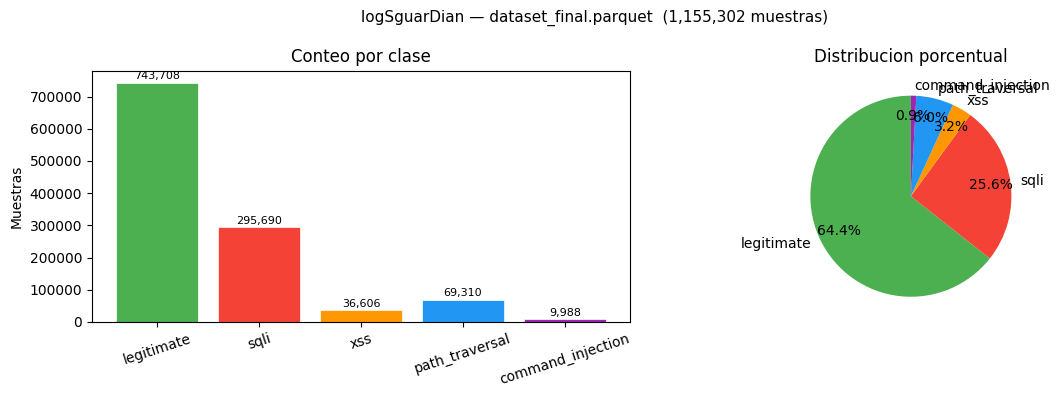

In [5]:
counts = df_final["label"].value_counts().sort_index()
total  = len(df_final)

print(f"{'lbl':<5} {'clase':<22} {'count':>10}  {'%':>6}")
print("-" * 50)
for lbl_int, cnt in counts.items():
    name = LABEL.get(int(lbl_int), "?")
    print(f"  {int(lbl_int):<3}  {name:<22} {cnt:>10,}  {100*cnt/total:>5.1f}%")
print("-" * 50)
print(f"  {'TOTAL':<25} {total:>10,}  100.0%")

ratio_legit_cmdi = counts[0] / counts[4]
print(f"\nRatio legitimate:command_injection = {ratio_legit_cmdi:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ["#4CAF50", "#F44336", "#FF9800", "#2196F3", "#9C27B0"]
labels = [LABEL[int(k)] for k in counts.index]

bars = axes[0].bar(labels, counts.values, color=colors, edgecolor="white", linewidth=0.5)
axes[0].set_title("Conteo por clase")
axes[0].set_ylabel("Muestras")
axes[0].tick_params(axis="x", rotation=18)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.003,
                 f"{val:,}", ha="center", va="bottom", fontsize=8)

axes[1].pie(
    counts.values,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    pctdistance=0.8,
)
axes[1].set_title("Distribucion porcentual")

plt.suptitle(f"logSguarDian — dataset_final.parquet  ({total:,} muestras)", fontsize=11)
plt.tight_layout()
plt.show()

In [6]:
df_final.head()

,sample_id,payload_length,payload_entropy,uri_length,path_length,query_string_length,body_length,body_entropy,path_depth,query_param_count,...,authorization_length,unusual_headers_count,status_code,req_count_1s,req_count_5s,req_count_60s,error_rate_4xx_60s,endpoint_diversity_60s,label,timestamp
0,payloads_csv_0,54.0,4.474898,116.0,41.0,74.0,0.0,0.0,3.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2026-06-08
1,payloads_csv_1,142.0,4.576990,223.0,60.0,162.0,0.0,0.0,5.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2026-06-08
2,payloads_csv_2,71.0,4.420354,119.0,39.0,79.0,0.0,0.0,4.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2026-06-08
3,payloads_csv_3,300.0,4.501073,372.0,59.0,312.0,0.0,0.0,5.0,18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2026-06-08
4,payloads_csv_4,142.0,4.576990,223.0,60.0,162.0,0.0,0.0,5.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2026-06-08
